In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [21]:
df=pd.read_csv("cardekho_imputated.csv")

In [22]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [23]:
df

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  object 
 1   brand              15411 non-null  object 
 2   model              15411 non-null  object 
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  object 
 6   fuel_type          15411 non-null  object 
 7   transmission_type  15411 non-null  object 
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.5+ MB


In [25]:
numerical_cols=df.select_dtypes(exclude="O").columns
numerical_cols=numerical_cols.to_list()
numerical_cols.remove("selling_price")
categorical_cols=df.select_dtypes(include="O").columns
categorical_cols=categorical_cols.to_list()


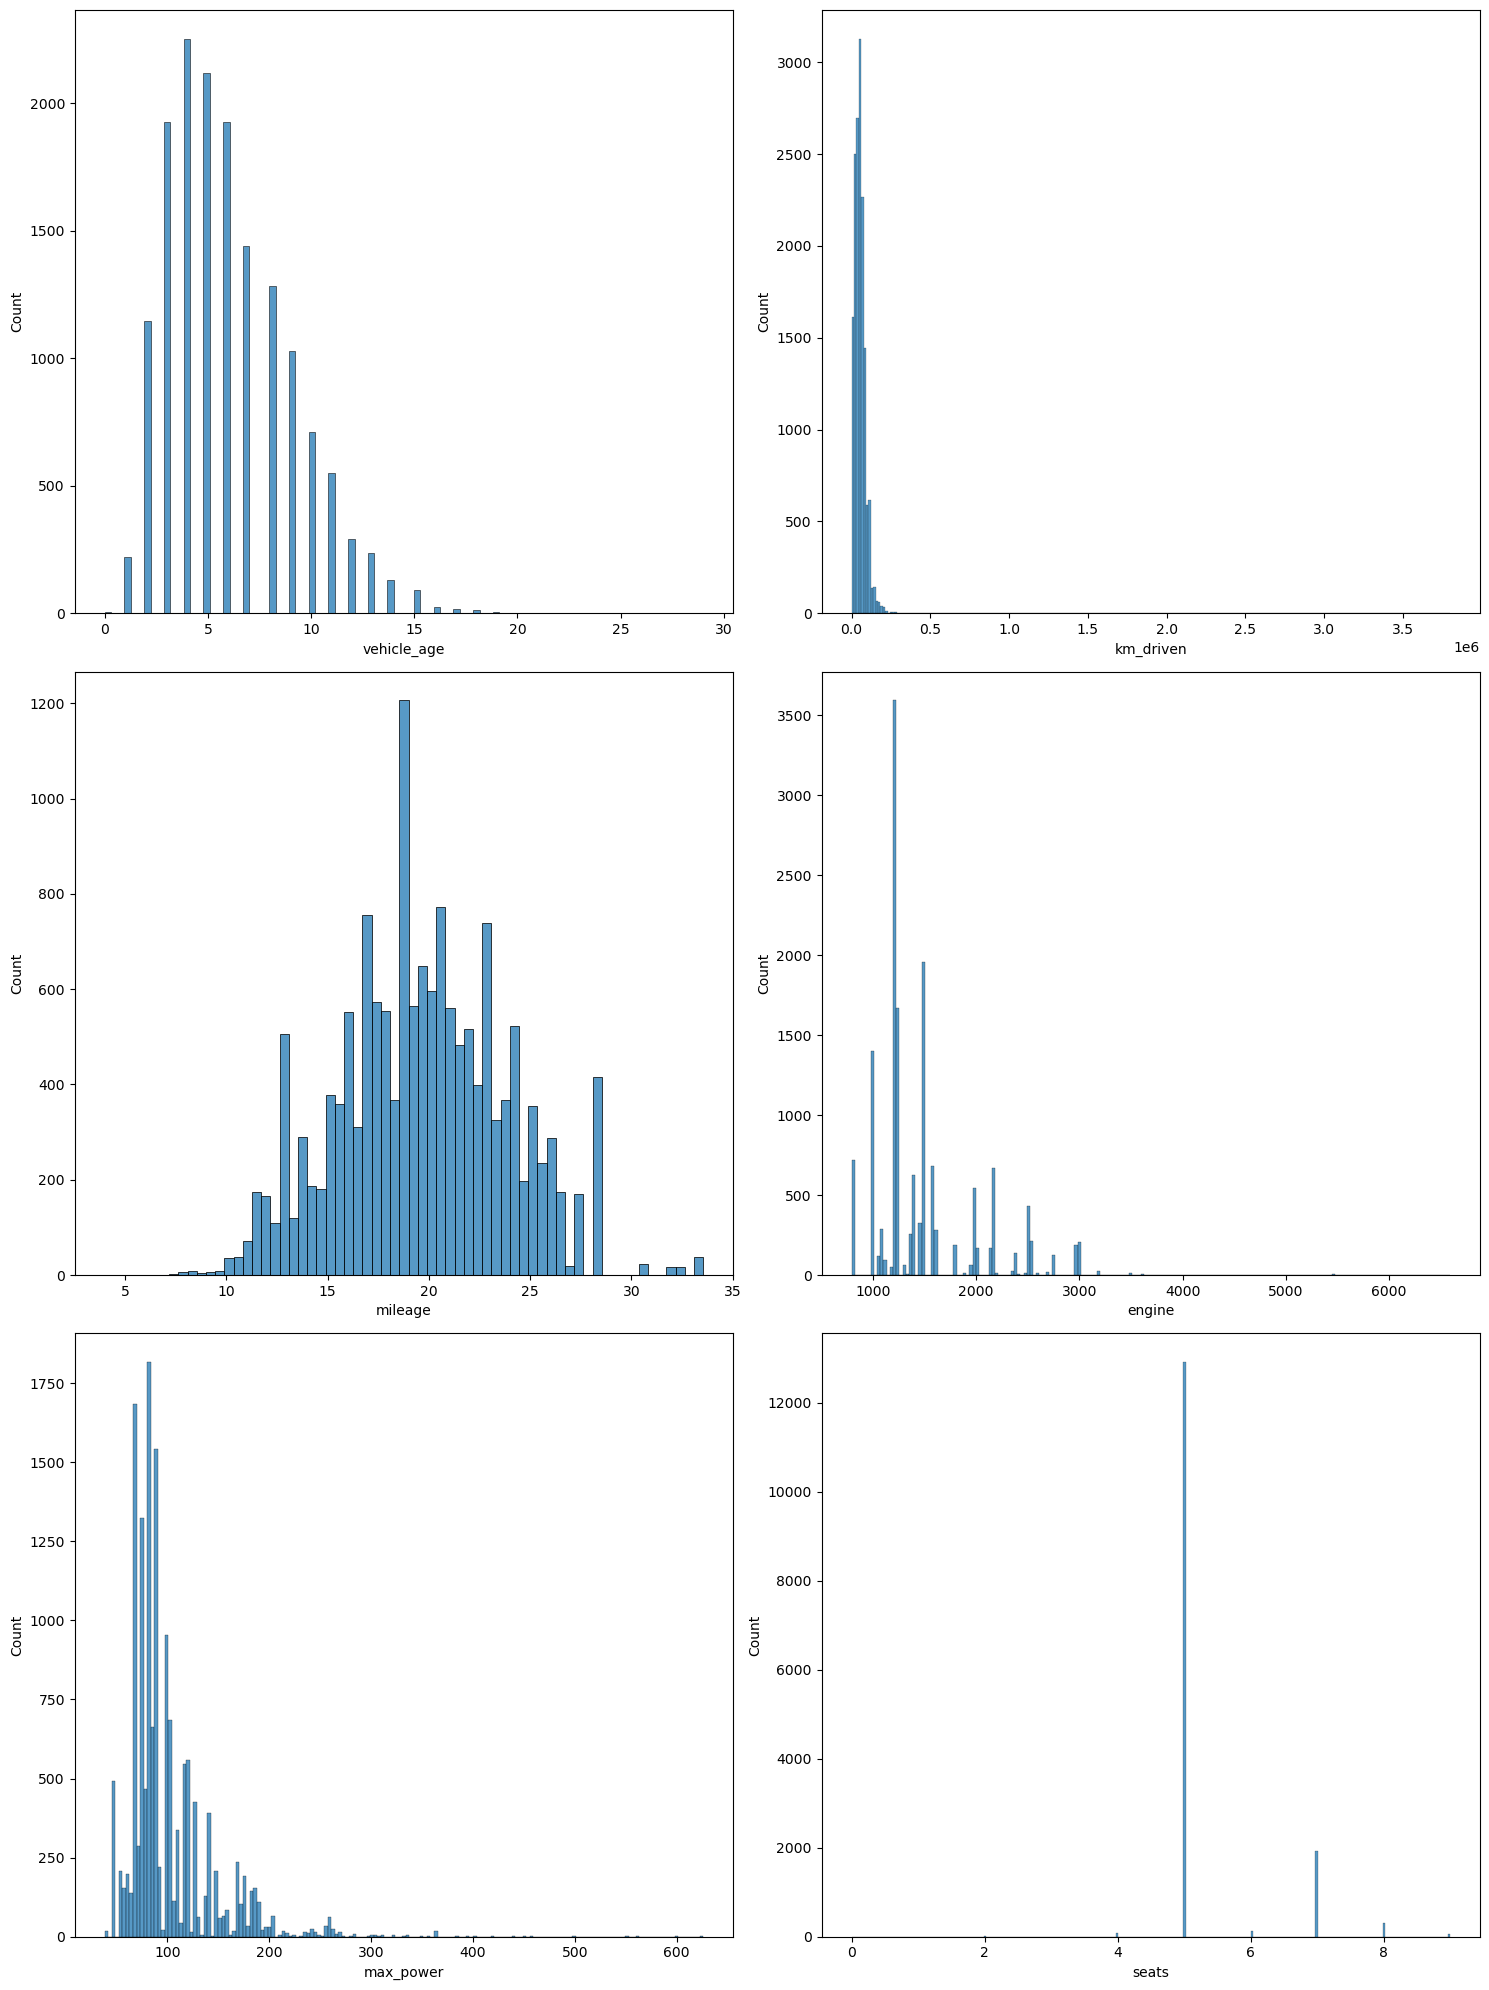

In [26]:
fig,ax=plt.subplots(3,2,figsize=(15,20))
for i,col in enumerate(numerical_cols):
    sns.histplot(data=df,x=col,ax=ax[i//2,i%2])
plt.tight_layout()

<Axes: xlabel='selling_price', ylabel='Count'>

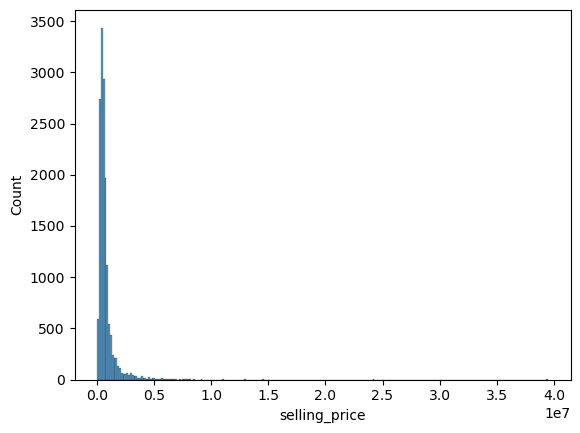

In [27]:
sns.histplot(data=df, x="selling_price")

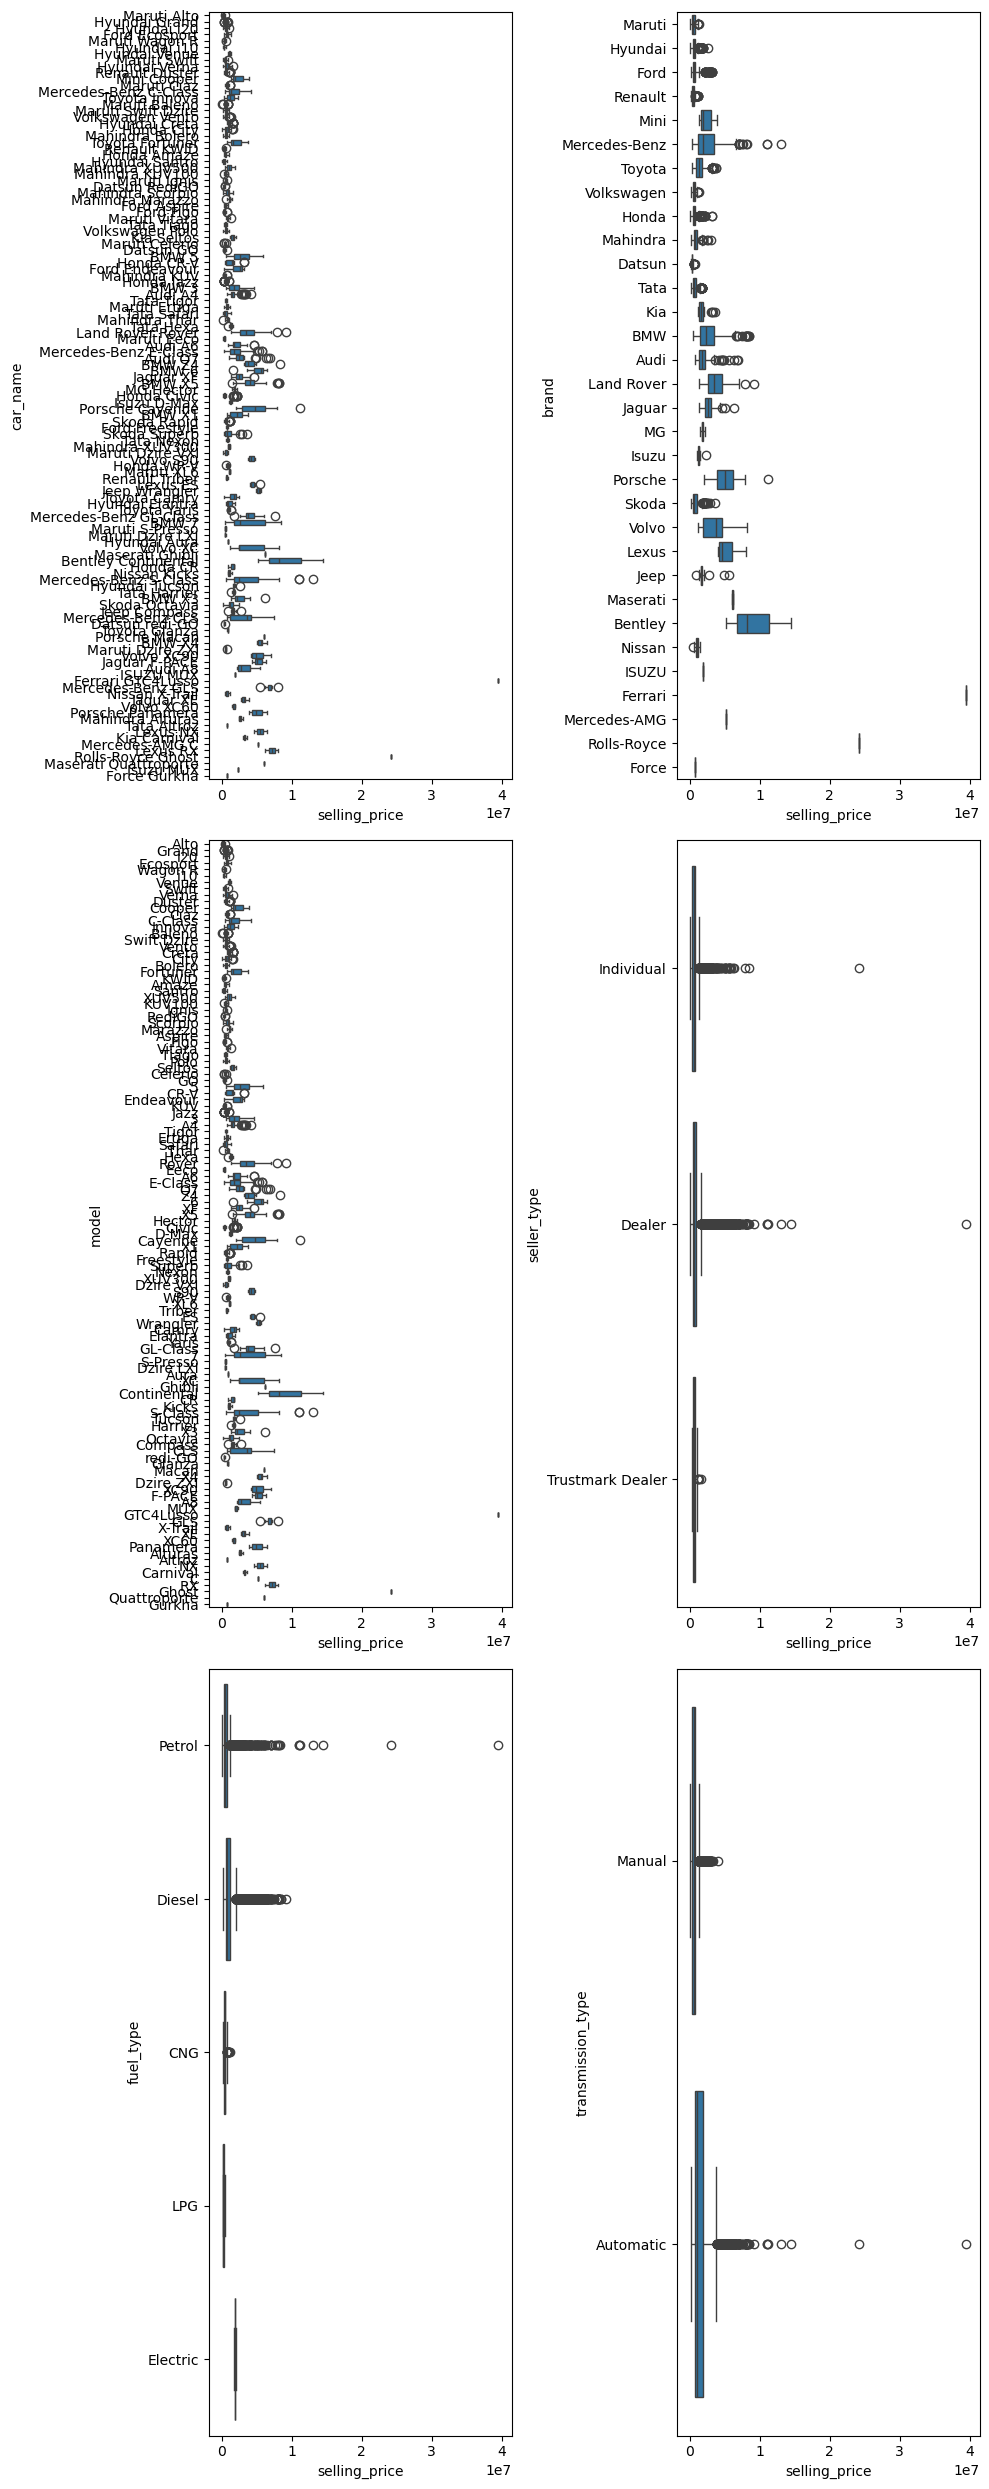

In [28]:
fig,ax=plt.subplots(3,2,figsize=(10,25))
for i,col in enumerate(categorical_cols):
    sns.boxplot(data=df,y=col,x="selling_price",ax=ax[i//2,i%2])
plt.tight_layout()

<Axes: >

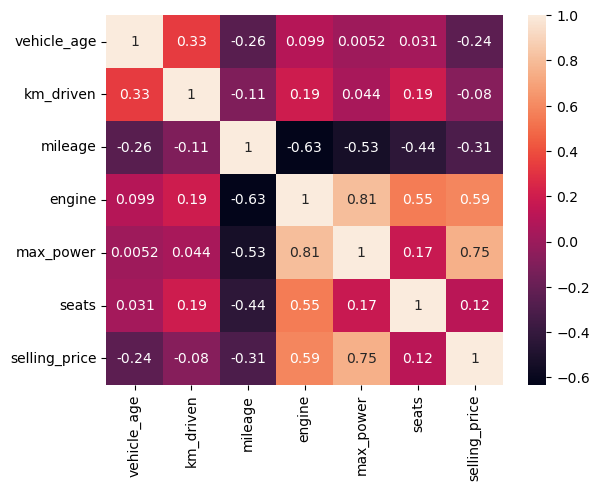

In [29]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

In [30]:
from scipy.stats import f_oneway

alpha = 0.05
anova_results = {}

for col in categorical_cols:
    groups = [
        group["selling_price"].dropna()
        for _, group in df.groupby(col)
    ]

    # Skip features with fewer than 2 groups
    if len(groups) < 2:
        continue

    f_stat, p = f_oneway(*groups)

    decision = "Keep Feature" if p < alpha else "Drop Feature"

    anova_results[col] = [f_stat, p, decision]

results_df = pd.DataFrame(
    anova_results,
    index=["F-Statistic", "P-Value", "Decision"]
).T

In [31]:
df.drop_duplicates(inplace=True)

In [32]:
X=df.drop("selling_price",axis=1)
y=df["selling_price"]

## Train test split

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Preprocessing

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

num_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

cat_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("OH_encoder",OneHotEncoder(handle_unknown="ignore",sparse_output=False))
])

preprocessor=ColumnTransformer([
    ("num_cols",num_pipeline,numerical_cols),
    ("cat_cols",cat_pipeline,categorical_cols)
],remainder="passthrough")
preprocessor

,transformers,"[('num_cols', ...), ('cat_cols', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [35]:
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    BayesianRidge,
    HuberRegressor,
    SGDRegressor,
    PassiveAggressiveRegressor,
    RANSACRegressor,
    OrthogonalMatchingPursuit
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    BaggingRegressor
)

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "Bayesian Ridge": BayesianRidge(),
    "Huber Regressor": HuberRegressor(),
    "SGD Regressor": SGDRegressor(random_state=42),
    "Passive Aggressive": PassiveAggressiveRegressor(random_state=42),
    "RANSAC": RANSACRegressor(random_state=42),
    "Orthogonal Matching Pursuit": OrthogonalMatchingPursuit(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "Bagging": BaggingRegressor(random_state=42),

    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),

    "MLP Regressor": MLPRegressor(random_state=42)
}

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

models.update({
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=42)
})


In [36]:
# from sklearn.model_selection import cross_val_score

# result={}

# for name,model in models.items():
#     pipeline=Pipeline([
#     ("preprocessor",preprocessor),
#     ("model",model)
#     ])
#     cv=cross_val_score(
#         pipeline,
#         X_train,
#         y_train,
#         cv=5,
#         n_jobs=-1
#     )
#     result[name]=cv.mean()

In [37]:
# sorted_results = sorted(result.items(), key=lambda x: x[1], reverse=True)

# for model, score in sorted_results:
#     print(model, score)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

rf_pipeline=Pipeline([
    ("oh",OneHotEncoder(handle_unknown="ignore",sparse_output=False)),
    ("model",RandomForestRegressor())
])

param_grid = {
    "model__max_depth": [None, 20, 40]
}

grid=GridSearchCV(
    rf_pipeline,
    param_grid,
    scoring="accuracy",
    cv=2,
    n_jobs=-1
)

grid.fit(X_train,y_train)

print(grid.best_score_)
print(grid.best_params_)

y_pred=grid.best_estimator_.predict(X_test)

print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

KeyboardInterrupt: 

In [ ]:
# complete